# Lower Freda Formation ca. 1075 Ma paleomagnetic pole

The lower Freda Formation is the basal portion of the Freda Formation, the
uppermost unit of the Oronto Group in the Midcontinent Rift (Keweenaw
Peninsula, Michigan / northern Wisconsin). The Oronto Group is a conformable
post-rift siliciclastic succession — Copper Harbor Conglomerate → Nonesuch
Formation → Freda Formation — deposited during thermal-subsidence sag of the rift
after ca. 1085 Ma volcanism. Its red-bed sandstones and siltstones carry a
detrital remanence that records Laurentia's continued equatorward motion along
the *Keweenawan Track* of the apparent polar wander path.

Henry, Mauk & Van der Voo (1977) sampled the lower Freda at the Presque Isle
River exposures (their localities HR1 and HR2), isolating a high-temperature
specularite detrital remanent magnetization (DRM) and a younger, shallow
pigmentary-hematite chemical remanence (CRM). Their specimen-level directions
(published in the Henry, 1976 MSc thesis) are archived in MagIC contribution
[16450](https://earthref.org/MagIC/16450) and reproduced here.

This pole is the *lower Freda* member of the Oronto Group APWP sequence analyzed
by Fuentes et al. (2025) (Nonesuch → lower Freda → upper Freda → Jacobsville):
they recompute it from the Henry et al. (1977) data and apply the same
inclination-shallowing-correction (SVEI) uncertainty propagation used for their
new upper Freda pole. The lower Freda lies near the paleo-equator,
so the shallowing correction is negligible.

This notebook reproduces:
- Henry et al.'s (1977) lower Freda DRM pole at **~1.2°N / 179.7°E** (matching
  their published 271.3°/+0.7° → 179.5°E/1.2°N and the legacy compilation
  "Freda Sandstone" pole of 2.2°N/179.0°E);
- the Fuentes et al. (2025) inclination-corrected (SVEI) pole at
  **~1.3°N / 179.8°E, A95 ≈ 2.6°**.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Specimen-level data (MagIC 16450)

The Henry et al. (1977) measurements (58 samples / 127 specimens of Nonesuch
Shale + Freda Sandstone; thermal, alternating-field and chemical demagnetization)
are pulled from MagIC contribution 16450 and cached locally so the notebook runs
offline. We compute a VGP for every specimen direction at the Presque Isle
sampling locality (≈ 46.8°N, 89.6°W).

In [2]:
pt.fetch_magic_contribution('16450', '../data/1075_Lower_Freda')

study_lat, study_lon = 46.8, -89.6   # Presque Isle River, lower Freda (HR1/HR2)

specimens = pd.read_csv('../data/1075_Lower_Freda/specimens.txt', sep='\t', skiprows=1)
specimens['lat'] = study_lat
specimens['lon'] = study_lon
specimens = ipmag.vgp_calc(specimens, tilt_correction='no', site_lon='lon', site_lat='lat',
                           dec_is='dir_dec', inc_is='dir_inc')

freda = specimens[specimens['description'] == 'Freda sandstone']
print('Freda sandstone specimens:', len(freda))
print('components:', freda['dir_comp'].value_counts().to_dict())

Download successful. File saved to: ../data/1075_Lower_Freda/magic_contribution_16450.txt
1  records written to file  /Users/unimos/0000_Github/2026_Laurentia_Precambrian_poles/data/1075_Lower_Freda/contribution.txt
31  records written to file  /Users/unimos/0000_Github/2026_Laurentia_Precambrian_poles/data/1075_Lower_Freda/sites.txt
121  records written to file  /Users/unimos/0000_Github/2026_Laurentia_Precambrian_poles/data/1075_Lower_Freda/samples.txt
313  records written to file  /Users/unimos/0000_Github/2026_Laurentia_Precambrian_poles/data/1075_Lower_Freda/specimens.txt
-I- Using MagIC contribution 16450 downloaded from earthref.org
Freda sandstone specimens: 244
components: {'PRIM': 174, 'SEC': 68, 'NRM': 2}


## Component directions

Two magnetization components are present in the Freda Sandstone:

- **PRIM** — the high-temperature specularite **DRM** (the primary, pole-bearing
  component). Following Fuentes et al. (2025) we use the tilt-corrected (`dir_tilt_correction = 100`)
  directions and drop a few specimens with `dec < 240°` (reversed/streaked
  endpoints), leaving the 85-specimen DRM population that matches the
  compilation's *N* = 85.
- **SEC** — a younger, shallow pigmentary-hematite **CRM** (Henry's secondary
  component), which defines a separate, nearby direction and is excluded from the
  pole.

DRM (PRIM, tilt-corrected): n = 85
CRM (SEC,  tilt-corrected): n = 34


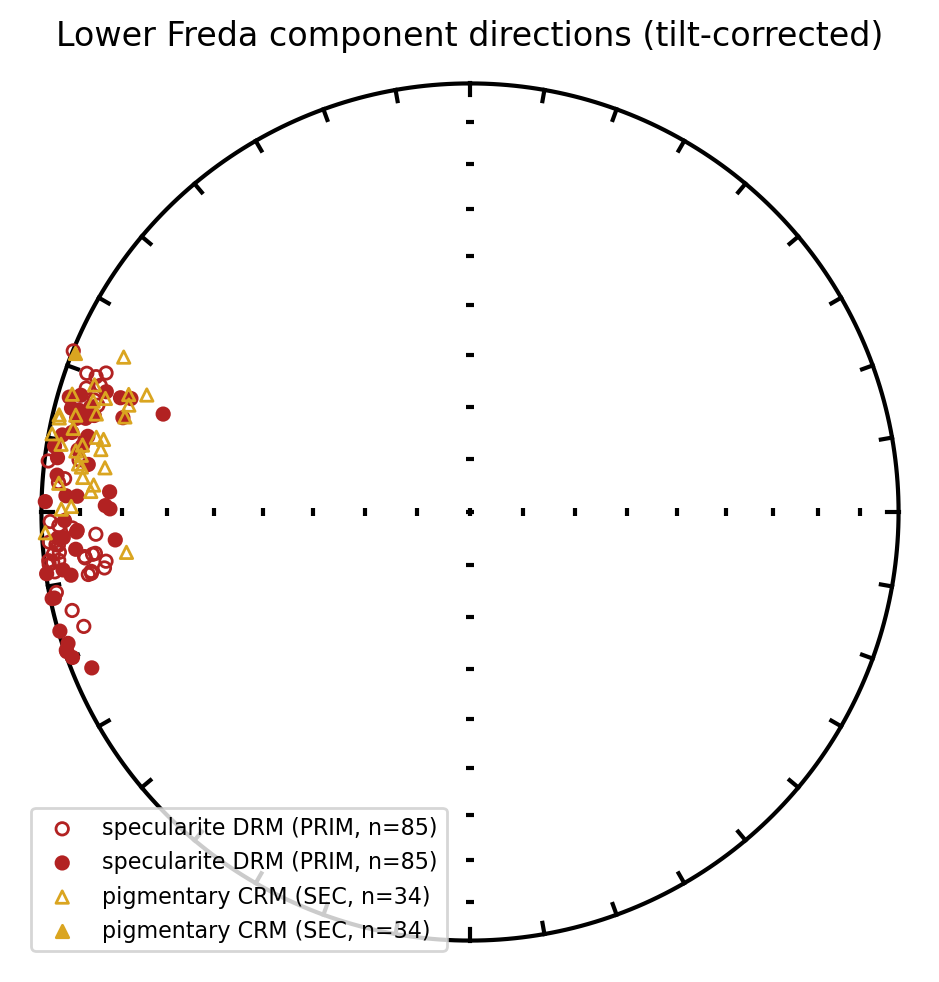

In [3]:
def freda_component(comp, tilt=100):
    d = freda[(freda['dir_comp'] == comp) & (freda['dir_tilt_correction'] == tilt)]
    d = d[d['dir_dec'] > 240]          # drop reversed/streaked endpoints
    return d.reset_index(drop=True)

DRM = freda_component('PRIM', tilt=100)    # high-T specularite DRM (the pole)
CRM = freda_component('SEC',  tilt=100)    # pigmentary-hematite CRM (separate)
print(f'DRM (PRIM, tilt-corrected): n = {len(DRM)}')
print(f'CRM (SEC,  tilt-corrected): n = {len(CRM)}')

ipmag.plot_net()
ipmag.plot_di(dec=DRM['dir_dec'].tolist(), inc=DRM['dir_inc'].tolist(),
              color='firebrick', marker='o', label=f'specularite DRM (PRIM, n={len(DRM)})')
ipmag.plot_di(dec=CRM['dir_dec'].tolist(), inc=CRM['dir_inc'].tolist(),
              color='goldenrod', marker='^', label=f'pigmentary CRM (SEC, n={len(CRM)})')
plt.legend(loc=3, fontsize=8)
plt.title('Lower Freda component directions (tilt-corrected)')
plt.show()

## As-measured DRM mean direction and pole

The Fisher mean of the 85 tilt-corrected DRM directions reproduces Henry et al.'s
(1977) published Freda Sandstone direction (D = 271.3°, I = +0.7°) and pole
(179.5°E, 1.2°N). The near-zero inclination places the site at the
paleo-equator.

In [4]:
dir_mean = ipmag.fisher_mean(dec=DRM['dir_dec'].tolist(), inc=DRM['dir_inc'].tolist())
print('As-measured DRM mean direction:')
ipmag.print_direction_mean(dir_mean)

flat_pole = ipmag.fisher_mean(DRM['vgp_lon'].tolist(), DRM['vgp_lat'].tolist())
print('\nAs-measured DRM pole:')
ipmag.print_pole_mean(flat_pole)

print('\nHenry et al. (1977) published: D = 271.3 / I = +0.7  ->  pole 179.5 E / 1.2 N')
print('Legacy compilation "Freda Sandstone":          pole 179.0 E / 2.2 N (A95 4.2)')

As-measured DRM mean direction:
Dec: 271.3  Inc: 0.7
Number of directions in mean (n): 85
Angular radius of 95% confidence (a_95): 2.8
Precision parameter (k) estimate: 30.7

As-measured DRM pole:
Plon: 179.7  Plat: 1.2
Number of directions in mean (n): 85
Angular radius of 95% confidence (A_95): 2.4
Precision parameter (k) estimate: 42.1

Henry et al. (1977) published: D = 271.3 / I = +0.7  ->  pole 179.5 E / 1.2 N
Legacy compilation "Freda Sandstone":          pole 179.0 E / 2.2 N (A95 4.2)


## Fold test and the timing of remanence acquisition

Midcontinent Rift inversion imparted **variable tilt** to the Freda Formation
between exposures (the gently dipping lower Freda beds sampled by Henry et al.,
1977, through to the more steeply tilted sections of the Ashland
Syncline / Montreal River Monocline). Fuentes et al. (2025) exploited this spread
to run a **regional bootstrap fold test** (Tauxe & Watson, 1994) on the *combined*
Freda directions — their new lower- and upper-Freda sections together with the
Henry et al. (1977) lower Freda data. The DRM directions cluster most tightly at
**95–102% unfolding** (95% confidence), and the pigmentary-hematite CRM at
97–104%; both ranges bracket complete unfolding, so **both magnetizations were
acquired prior to tilting**.

This is a *tight* temporal constraint. The tilting records Grenvillian
contractional inversion of the rift — the Ottawan-to-Rigolet phases — dated by
**Douglas Fault vein calcite at 1,049 ± 13 Ma** (U-Pb; Hodgin et al., 2024) and
continuing until the ca. 990 Ma sub-Jacobsville unconformity, i.e. deformation
spanning roughly **1050–1000 Ma**. Because the lower Freda was deposited at
ca. 1075 Ma and tilted only ~25–75 Myr later, a pre-folding remanence is pinned
to the narrow window between deposition and inversion — strong evidence that the
specularite DRM is the **primary, ca. 1075 Ma depositional** magnetization rather
than a later overprint.

## Inclination-shallowing correction (E/I)

Detrital remanence in red beds can be shallowed by compaction. Fuentes et al.
(2025) applied the same flattening-factor uncertainty propagation (SVEI; Tauxe et
al., 2024; Pierce et al., 2022 Monte Carlo) to the lower Freda data of Henry et
al. (1977) as to their upper Freda pole, with the same *f* confidence interval.

Because the lower Freda inclinations are **so shallow (≈ 0°, both upward and
downward)**, the correction has a *minor* effect — unsquishing changes the pole
by a fraction of a degree. We show this deterministically by un-flattening the
DRM inclinations (this is the operation behind Fuentes' `Henry_ht_pole`) for the
study best-fit *f* = 0.48 and for the blanket sedimentary *f* = 0.6, recomputing
the VGP-mean pole each time.

In [5]:
def unflattened_pole(dirs, f):
    inc_corr = ipmag.unsquish(dirs['dir_inc'].tolist(), f)
    d = dirs.copy()
    d['dir_inc'] = inc_corr
    d = ipmag.vgp_calc(d, tilt_correction='no', site_lon='lon', site_lat='lat',
                       dec_is='dir_dec', inc_is='dir_inc')
    direction = ipmag.fisher_mean(dec=d['dir_dec'].tolist(), inc=inc_corr)
    pole = ipmag.fisher_mean(d['vgp_lon'].tolist(), d['vgp_lat'].tolist())
    return direction, pole

for f in (0.48, 0.60):
    cdir, cpole = unflattened_pole(DRM, f)
    print('f = %.2f :  corrected I = %4.1f   ->  pole %.1f N / %.1f E  (A95 %.1f)'
          % (f, cdir['inc'], cpole['inc'], cpole['dec'], cpole['alpha95']))

corr_dir, corr_pole = unflattened_pole(DRM, 0.60)   # blanket sedimentary f for the Nordic f-block

print('\nFuentes et al. (2025) reported SVEI pole (Table 1):  1.3 N / 179.8 E, A95 2.6')
print('As-measured pole (this notebook):                   %.1f N / %.1f E, A95 %.1f'
      % (flat_pole['inc'], flat_pole['dec'], flat_pole['alpha95']))

f = 0.48 :  corrected I =  1.2   ->  pole 1.4 N / 179.9 E  (A95 2.9)
f = 0.60 :  corrected I =  1.1   ->  pole 1.3 N / 179.8 E  (A95 2.7)

Fuentes et al. (2025) reported SVEI pole (Table 1):  1.3 N / 179.8 E, A95 2.6
As-measured pole (this notebook):                   1.2 N / 179.7 E, A95 2.4


## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(179.6877111409824),
 'Inc': np.float64(1.171597749237157),
 'N': 85,
 'Mu': np.float64(2.330178836868349),
 'Mu_critical': 1.207,
 'Me': np.float64(0.7526891840689084),
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

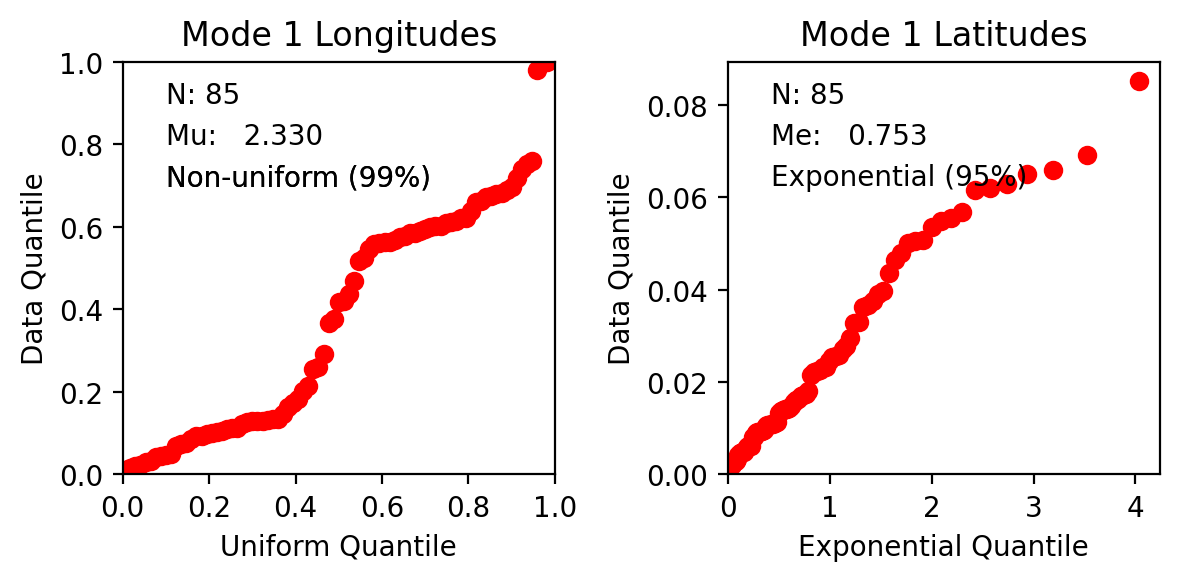

In [6]:
fishqq_result = pt.fishqq_vgps(DRM, unify_polarity=False)
fishqq_result

(SVEI elongation plot skipped: E below the TK03.GAD model minimum)
paleolatitude = 0.3 deg; elongation E = 2.11 (inconsistent with TK03.GAD)


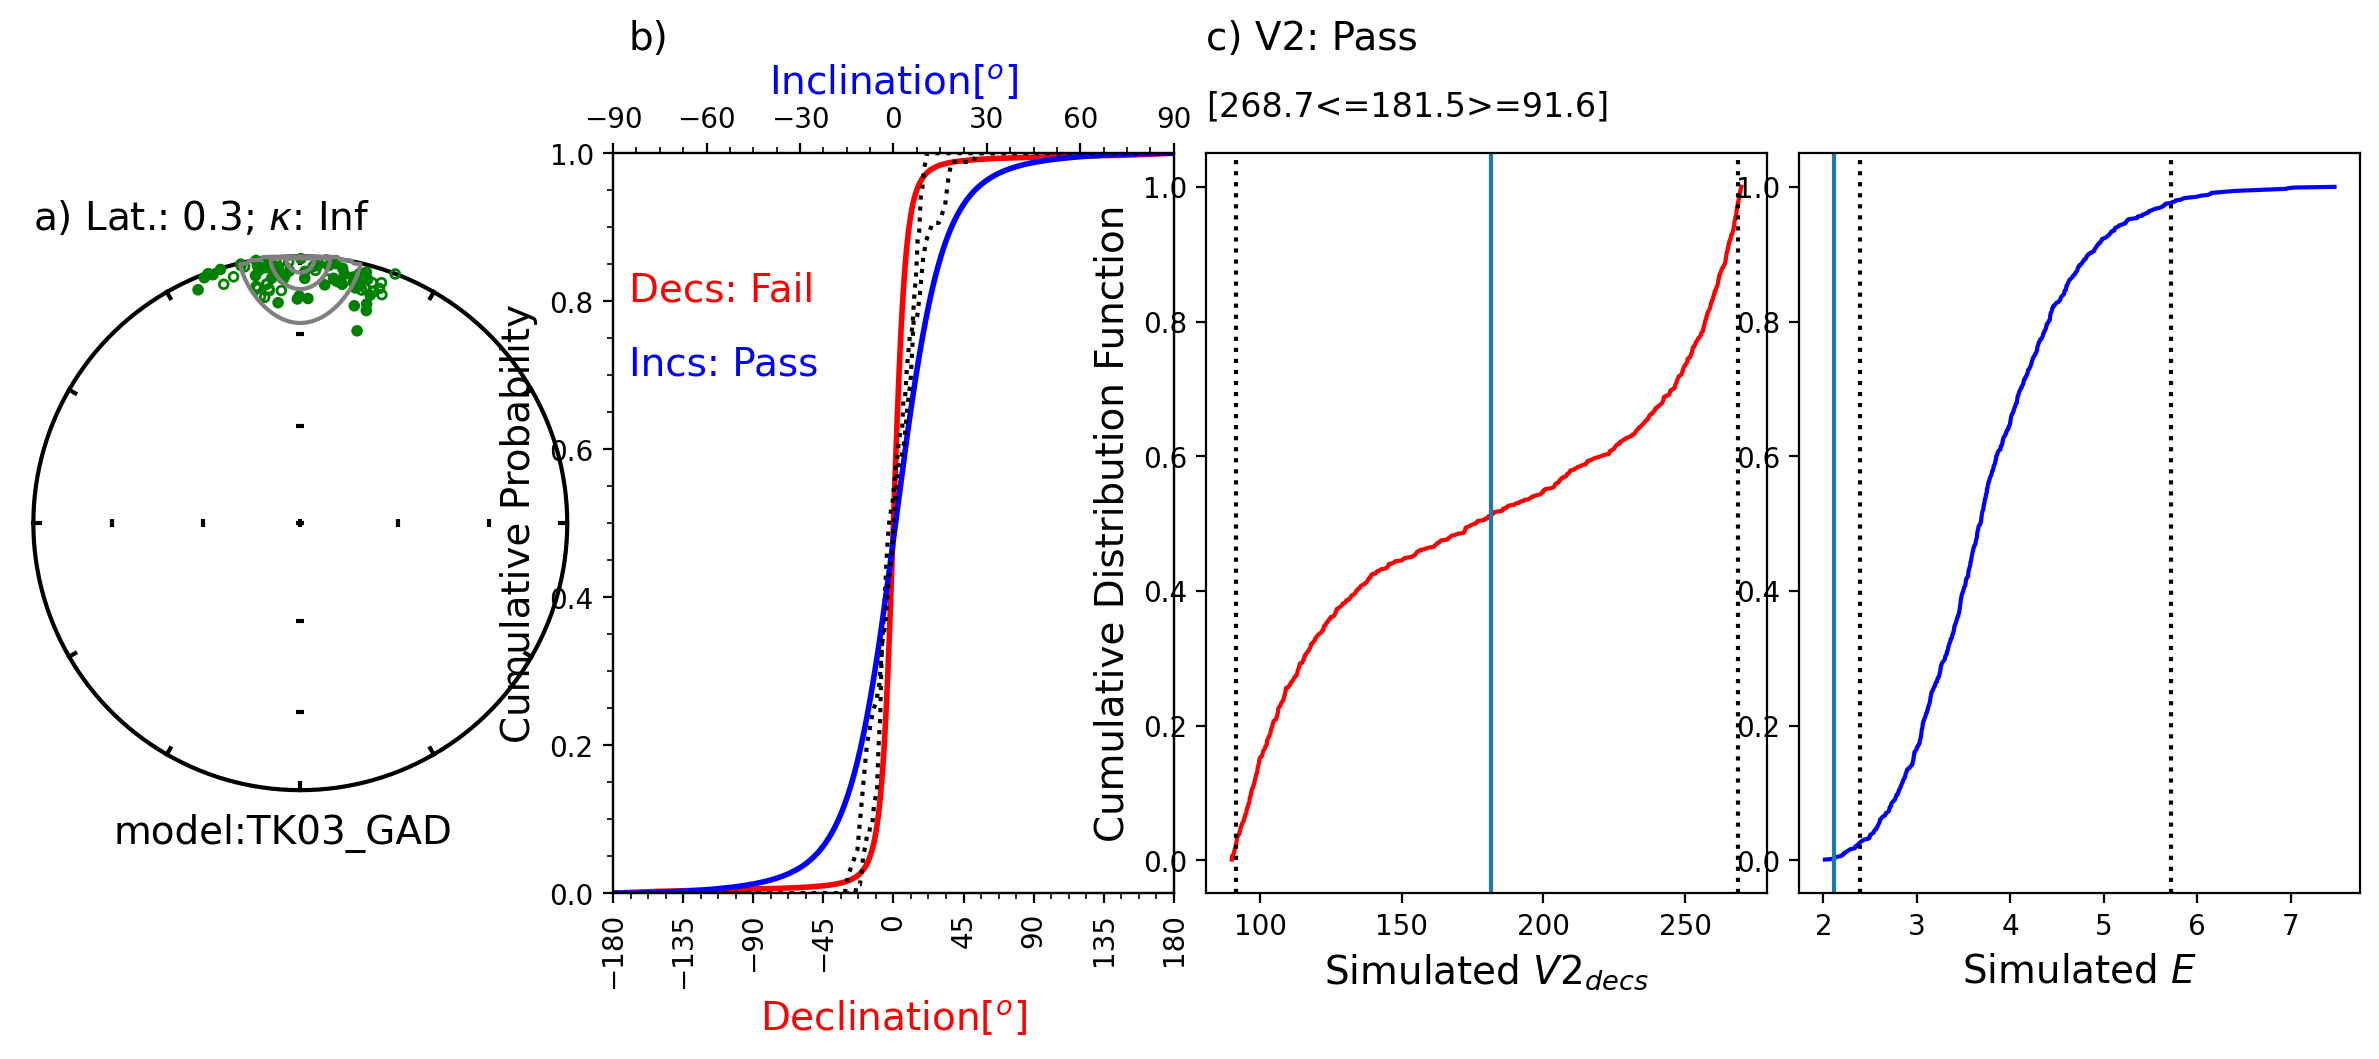

In [7]:
_slat, _slon = float(DRM['lat'].mean()), float(DRM['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(DRM, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(DRM, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## Pole in the context of the Laurentia APWP

The lower Freda pole sits between the slightly older Nonesuch pole (≈ 6.6°N) and
the younger upper Freda pole on the Keweenawan Track, recording Laurentia's
progression toward the equator after the end of rift volcanism.

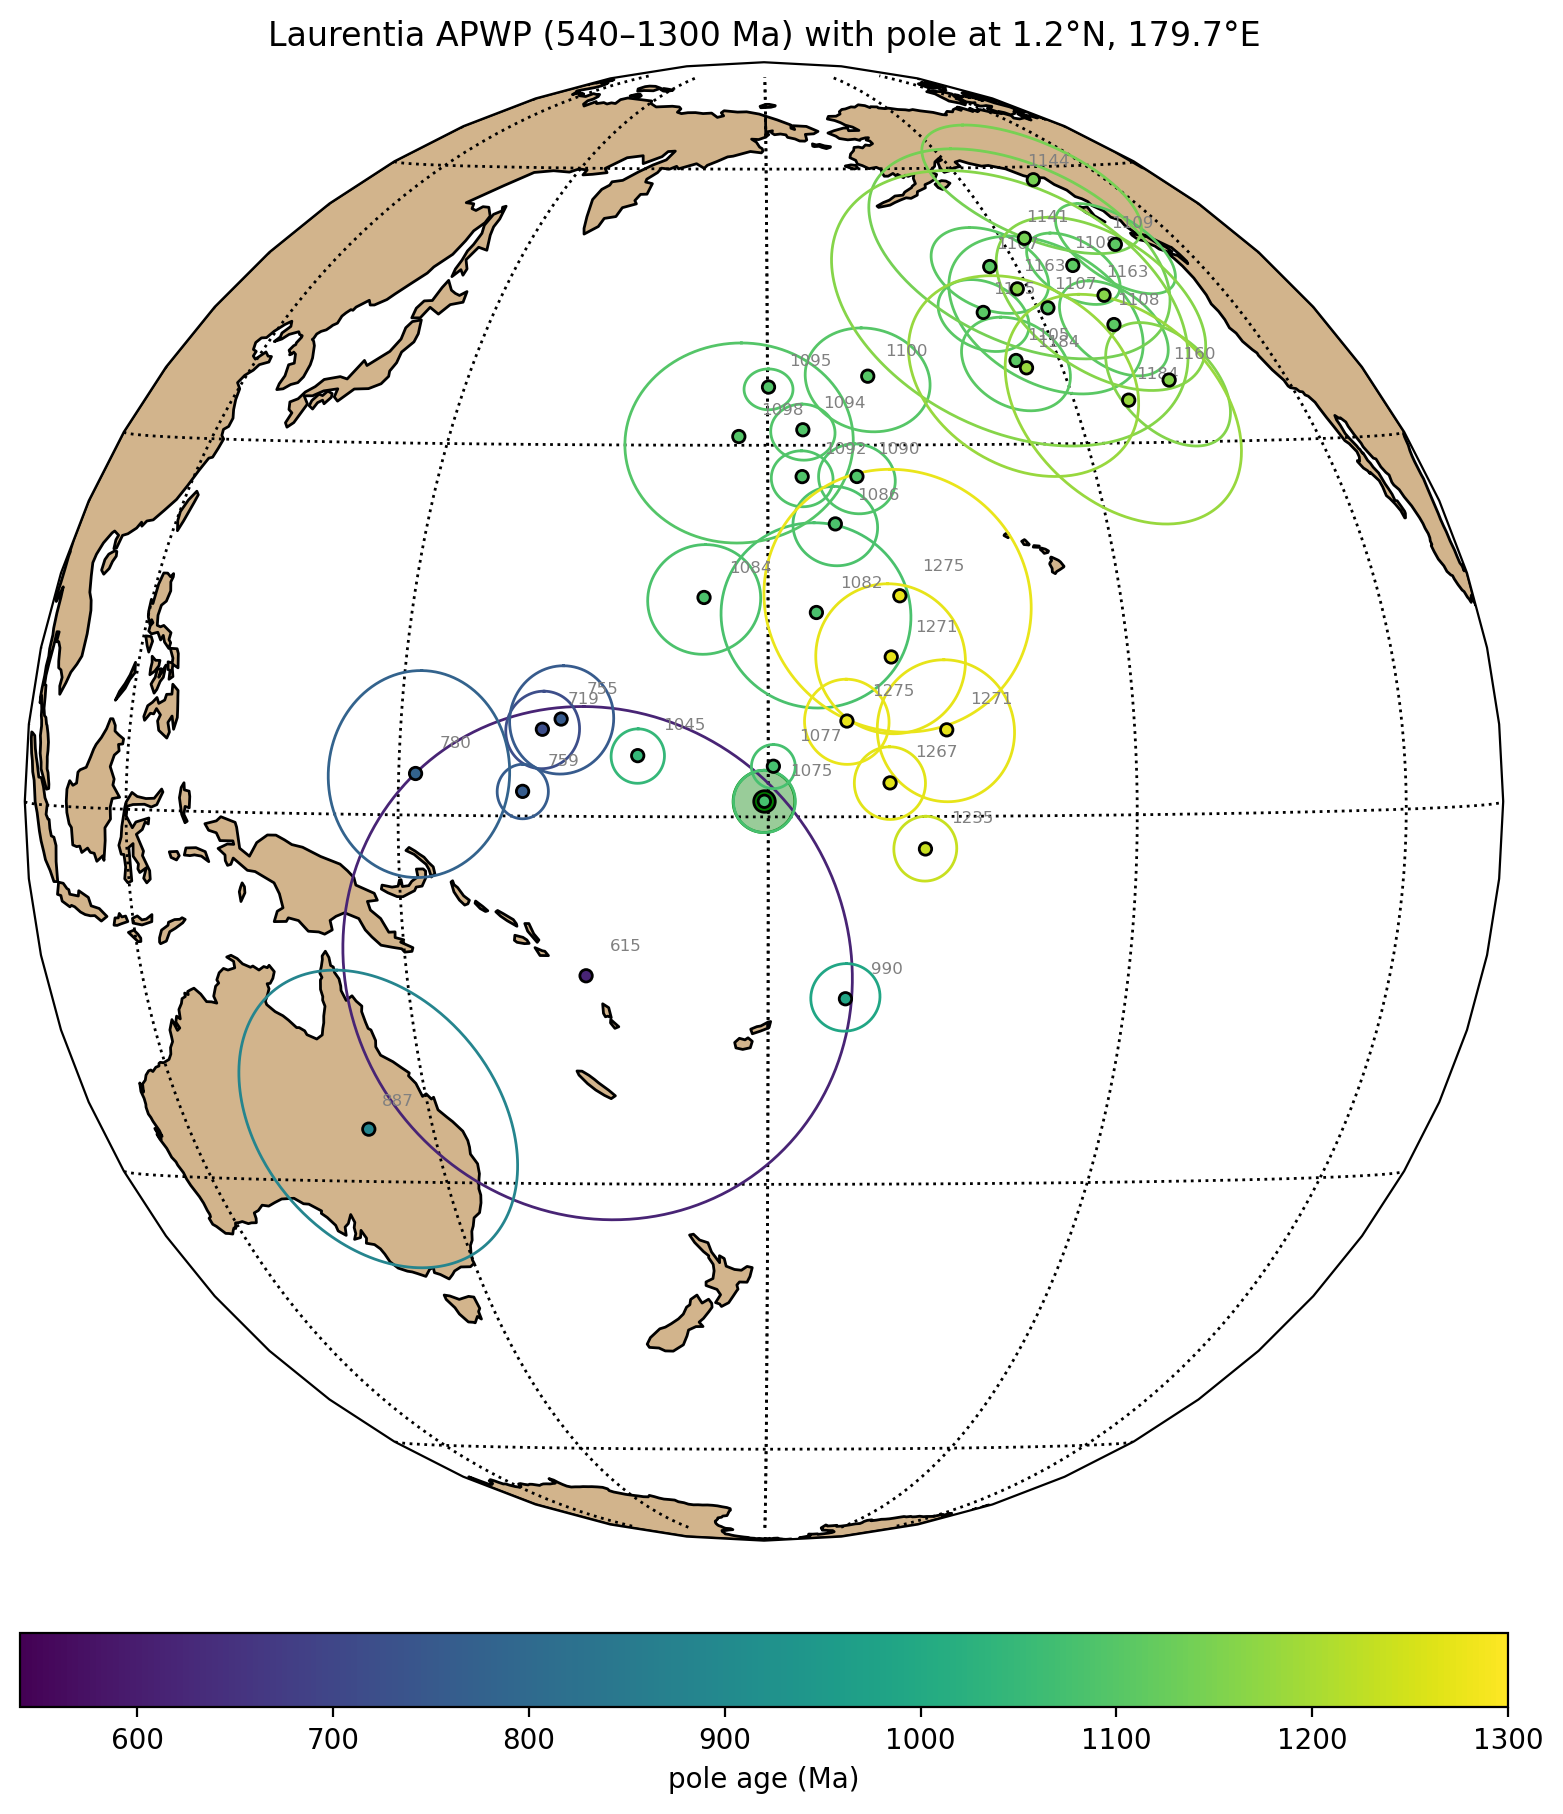

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, flat_pole['inc'], flat_pole['dec'],
                          flat_pole['alpha95'], age_min=540, age_max=1300,
                          projection='orthographic',
                          central_longitude=flat_pole['dec'],
                          central_latitude=flat_pole['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

The lower Freda pole should resemble other ca. 1075 Ma Laurentia poles but be
distinct from younger (Grenvillian and Neoproterozoic) poles — i.e. it should not
overlap the Phanerozoic-to-early-Neoproterozoic apparent polar wander path,
guarding against a younger remagnetization.

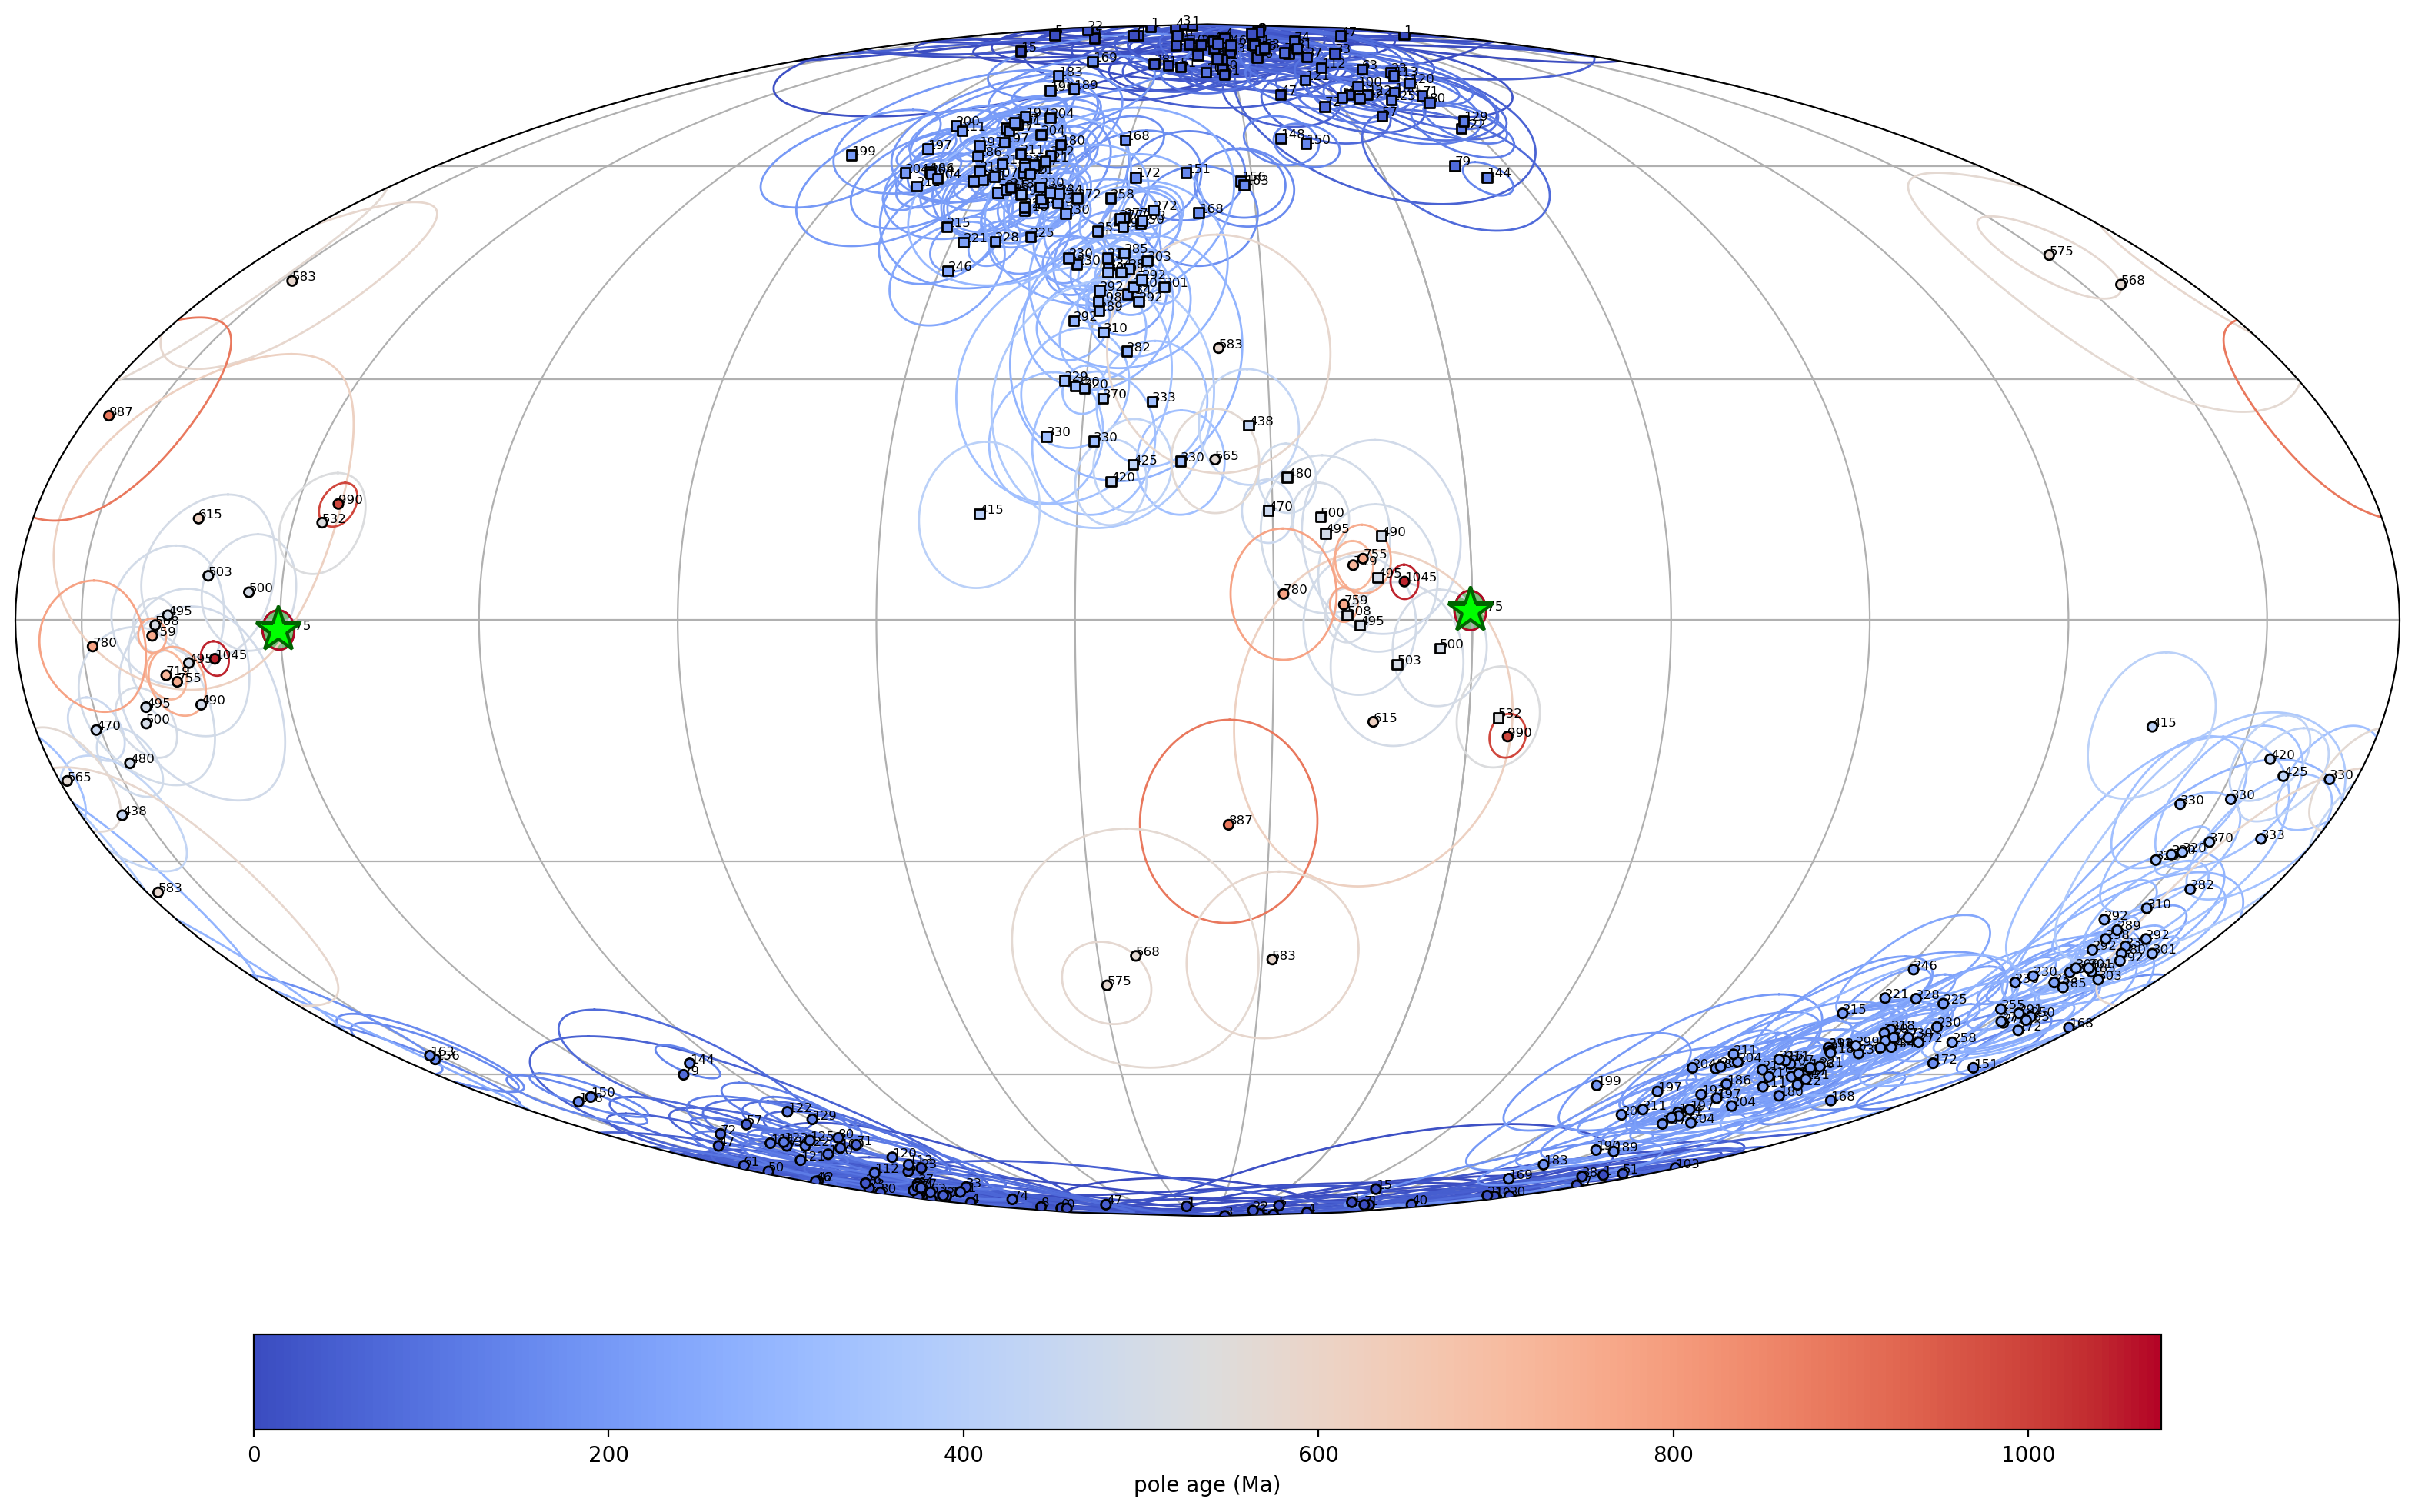

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
_ = pt.plot_pole_overlap('Freda Sandstone', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=flat_pole['inc'], pole_plon=flat_pole['dec'],
                     pole_A95=flat_pole['alpha95'], pole_age=1075)

## R-score summary (Meert et al., 2020)

Reliability assessment carried from the Nordic Workshop compilation
("Freda Sandstone", GPMDB 2051), reflecting Henry et al.'s (1977) study:

| Criterion | Value | Basis |
|---|---|---|
| **R1** age | 0 | Age from the Bayesian thermal-subsidence model, not a direct date on the sampled section |
| **R2** statistics | 1 | n = 85, A95 = 2.4° (< 16°); adequate sampling |
| **R3** demag | 1 | Thermal + AF + chemical demagnetization, vector subtraction of components |
| **R4** field test | f | Positive regional bootstrap fold test on combined Freda directions (95–102% unfolding; Fuentes et al., 2025), bracketing pre-tilting (ca. 1075 Ma) acquisition |
| **R5** reversals | 0 | Single (normal-track) polarity, no reversal test |
| **R6** rotation | 0 | No independent test against vertical-axis rotation |
| **R7** younger overprint | 1 | DRM distinct from the younger pigmentary CRM and consistent with the Keweenawan Track |

**R = 4 → Grade B.**

## Nordic workshop ranking

### Specularite DRM pole

| | This study (site VGPs) | Henry et al. (1977) | Previous Nordic compilation |
|---|---|---|---|
| Component | high-temperature specularite DRM | Freda Sandstone | High temp. |
| N (sites) | 85 | 85 | 20 |
| N (specimens) | 85 | 85 | 85 |
| Dec (°) | 271.3 | 271.3 | 272.4 |
| Inc (°) | 0.7 | 0.7 | 1.5 |
| k (direction) | 30.7 | 31 | 32.0 |
| α95 (direction, °) | 2.8 | 3.0 | 5.9 |
| Pole lat (°N) | 1.2 | 1.2 | 2.2 |
| Pole lon (°E) | 179.7 | 179.5 | 179.0 |
| A95 | 2.4 | — | 4.2 |
| dp / dm (°) | — | 1.4 / 2.8 | 3.0 / 5.9 |


In [10]:
# Nordic summary: main block = as-measured (flattened); inclination-corrected pole recorded in the Comment.
sites_df = pd.DataFrame({'dir_tilt_correction': [100] * len(DRM),
                         'dir_n_samples': [1] * len(DRM)})   # n = 85 specimen directions

Lower_Freda_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Lower Freda Formation',
    sites=sites_df,
    dir_mean=dir_mean,
    pole_mean=flat_pole,
    study_lon=study_lon % 360,
    study_lat=study_lat,
    lithology='sedimentary',
    component_comment='High-temperature specularite detrital remanent magnetization (DRM); a younger pigmentary-hematite CRM is excluded',
    tests='G+ (positive intraformational conglomerate test on fluvial intraclasts within this formation; Swanson-Hysell, Fairchild & Slotznick, 2019b), f+ (positive regional bootstrap fold test on the combined Freda directions, 95-102% unfolding; Fuentes et al., 2025); pre-tilting acquisition predates Grenvillian inversion (Douglas Fault calcite 1049 +/- 13 Ma, Hodgin et al., 2024)',
    gpmdb_number='2051',
    magic_id='16450',
    percent_reversed=0,
    demag_code=3,
    R1=0, R2=1, R3=1, R4='Gf', R5=0, R6=0, R7=1, Grade='B', Grade_E21='B',
    nominal_age=1075, lomagage=1063.3, himagage=1084.8,
    REF_method='Bayesian thermal-subsidence age model 1075.2 Ma (95% CI 1084.8/1063.3) (Fuentes et al., 2025), bracketed by the underlying Nonesuch Formation (ca. 1077 Ma) and the upper Freda detrital-zircon MDA 1051.6 +/- 1.1 Ma (Hodgin et al., 2024).',
    POLE_AUTHORS='Henry, S. G., Mauk, F. J., & Van der Voo, R.',
    YEAR=1977,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME=14,
    VPAGES='1128-1138',
    TITLE='Paleomagnetism of the upper Keweenawan sediments: Nonesuch Shale and Freda Sandstone',
    COMMENT=pt.corrected_pole_note('SVEI (Tauxe et al., 2024)', corr_pole['inc'], corr_pole['dec'],
                                   f=0.6, f_range=(0.59, 0.87), a95=corr_pole['alpha95'],
                                   monte_carlo='Pierce et al. (2022) Monte Carlo')
            + ' Lower Freda DRM pole from the Presque Isle River exposures (n=85 specularite specimens; Henry et al., 1977, specimen data in the Henry 1976 thesis; MagIC 16450). At the near-equatorial paleolatitude the inclination correction is negligible: Fuentes et al. (2025) report the SVEI pole at 1.3N/179.8E (A95 2.6). Nordic main/f-blocks use the blanket sedimentary f=0.6.'
)
pt.save_nordic_summary(Lower_Freda_summary, '1075_Lower_Freda')
Lower_Freda_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Lower Freda Formation,2051,16450,High-temperature specularite detrital remanent...,G+ (positive intraformational conglomerate tes...,100,46.8,270.4,85,...,Bayesian thermal-subsidence age model 1075.2 M...,Lower Freda Formation,"Henry, S. G., Mauk, F. J., & Van der Voo, R.",1977,Canadian Journal of Earth Sciences,14,1128-1138,Paleomagnetism of the upper Keweenawan sedimen...,Study inclination-corrected pole - SVEI (Tauxe...,
